<a href="https://colab.research.google.com/github/angelfrancomorales/INFO648/blob/main/Problem_Set_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Homework: Inference with Winsorized Weekly Earnings by Sex (2024 vs 2025)**

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [40]:
df=pd.read_csv('cps_with_education-1 (1).csv')
print(df.shape)
print(df.columns.tolist())
print(df.head())

(5553935, 8)
['Unnamed: 0', 'YEAR', 'UHRSWORKT', 'EARNWEEK2', 'AGE', 'SEX', 'STATEFIP', 'education']
   Unnamed: 0  YEAR  UHRSWORKT  EARNWEEK2  AGE  SEX  STATEFIP     education
0           0  2020         40        0.0   63    2        23  Some College
1           1  2020        999        0.0   67    1        23  Some College
2           2  2020         48      654.0   64    1        23  Some College
3           3  2020        999        0.0   71    2        23  Less than HS
4           4  2020         44        0.0   54    2        23  Some College


In [41]:
#Keep only 2024 and 2025
df=df[df['YEAR'].isin([2024, 2025])]

#Remove invalid earnings: drop 999999.99 (topcode) and anything <0
df=df[(df['EARNWEEK2'] > 0) & (df['EARNWEEK2'] != 999999.99)]

print("Rows after cleaning:", len(df))
print("Years:", df['YEAR'].unique())
print("Sex values:", df['SEX'].unique())  # 1=male, 2=female

Rows after cleaning: 240246
Years: [2024 2025]
Sex values: [1 2]


# **Part A: Winsorization**

In [42]:
Men24   = df[(df['SEX'] == 1) & (df['YEAR'] == 2024)]['EARNWEEK2'].copy()
Men25   = df[(df['SEX'] == 1) & (df['YEAR'] == 2025)]['EARNWEEK2'].copy()
Women24 = df[(df['SEX'] == 2) & (df['YEAR'] == 2024)]['EARNWEEK2'].copy()
Women25 = df[(df['SEX'] == 2) & (df['YEAR'] == 2025)]['EARNWEEK2'].copy()

print("Sizes:", len(Men24), len(Men25), len(Women24), len(Women25))

Sizes: 66587 55953 64001 53705


In [43]:
def winsorize_95(series):
  cutoff=series.quantile(0.95)
  winsorized=series.clip(upper=cutoff)
  return winsorized,cutoff
Men24_winsorized,Men24_cutoff=winsorize_95(Men24)
Men25_winsorized,Men25_cutoff=winsorize_95(Men25)
Women24_winsorized,Women24_cutoff=winsorize_95(Women24)
Women25_winsorized,Women25_cutoff=winsorize_95(Women25)
print("Cutoffs:", Men24_cutoff, Men25_cutoff, Women24_cutoff, Women25_cutoff)

part_a= pd.DataFrame()
part_a['Group']=['Men 2024', 'Men 2025', 'Women 2024', 'Women 2025']
part_a['Cutoffs']=[Men24_cutoff, Men25_cutoff, Women24_cutoff, Women25_cutoff]
part_a['Sample Size'] = [len(Men24), len(Men25), len(Women24), len(Women25)]

print(part_a.to_string(index=False))

Cutoffs: 3660.0 3860.0 2880.0 2975.9999999999127
     Group  Cutoffs  Sample Size
  Men 2024   3660.0        66587
  Men 2025   3860.0        55953
Women 2024   2880.0        64001
Women 2025   2976.0        53705


# **Part B: Confidence Intervals for Population Mean Earnings**

In [44]:
def conf_interval_95(series):
  n=len(series)
  xbar=series.mean()
  s=series.std(ddof=1)
  se=s/np.sqrt(n)
  z=1.96
  lower=xbar-z*se
  upper=xbar+z*se
  return xbar,s,n,lower,upper

results = {}
for name, data in [('Men2024',Men24_winsorized), ('Men2025', Men25_winsorized), ('Women2024', Women24_winsorized), ('Women2025', Women25_winsorized)]:
  xbar,s,n,lower,upper=conf_interval_95(data)
  results[name]={'mean':xbar, 'std':s, 'n':n, 'CI_lower':lower, 'CI_upper':upper}
  print(f"{name}:mean=${xbar:.2f}, 95% CI = [{lower:.2f}, {upper:.2f}]")

Men2024:mean=$1411.77, 95% CI = [1404.82, 1418.72]
Men2025:mean=$1483.18, 95% CI = [1475.07, 1491.30]
Women2024:mean=$1091.93, 95% CI = [1086.34, 1097.53]
Women2025:mean=$1128.71, 95% CI = [1122.38, 1135.04]


A 95% confidence interval indicates a 95% probability that the true population means of weekly earnings fall within the specified range of each group. For mThe 2025 interval $1475.07,$1491.30 is higher and does not overlap with the 2024 interval of $1404.82,$1418.72, indicating an increase in the mean weekly earnings from 2024 to 2025. Similar to women's 2025 interval $1122.38,$1135.04 is higher and does not overlap with the 2024 interval of $1086.34,$1097.53 which shows an increase in mean weekly earnings. The absence of overlap between each year and both sexes suggests that these increases are statistically significant and not due to random sampling variation.

# **Part C: Hypothesis Tests: Did the Population Mean Change?**

In [45]:
#Men:2024 vs 2025
t_men, p_men = stats.ttest_ind(Men25_winsorized, Men24_winsorized, equal_var=False)
diff_men = results['Men2025']['mean'] - results['Men2024']['mean']

#Women:2024 vs 2025
t_women, p_women = stats.ttest_ind(Women25_winsorized, Women24_winsorized, equal_var=False)
diff_women = results['Women2025']['mean'] - results['Women2024']['mean']

print("=== MEN ===")
print(f"  Mean 2024: ${results['Men2024']['mean']:.2f}")
print(f"  Mean 2025: ${results['Men2025']['mean']:.2f}")
print(f"  Difference (2025-2024): ${diff_men:.2f}")
print(f"  t-statistic: {t_men:.4f},  p-value: {p_men:.4e}")

print("\n=== WOMEN ===")
print(f"  Mean 2024: ${results['Women2024']['mean']:.2f}")
print(f"  Mean 2025: ${results['Women2025']['mean']:.2f}")
print(f"  Difference (2025-2024): ${diff_women:.2f}")
print(f"  t-statistic: {t_women:.4f},  p-value: {p_women:.4e}")

=== MEN ===
  Mean 2024: $1411.77
  Mean 2025: $1483.18
  Difference (2025-2024): $71.41
  t-statistic: 13.1005,  p-value: 3.4888e-39

=== WOMEN ===
  Mean 2024: $1091.93
  Mean 2025: $1128.71
  Difference (2025-2024): $36.78
  t-statistic: 8.5296,  p-value: 1.4866e-17


By looking at the p-value for both men and women, there is a statistically significant difference in weekly earnings between 2024 and 2025. Based on these results, there is sufficient evidence to reject the null hypothesis.

# **Part D: Statistical vs. Practical Significance**

In [46]:
def cohens_d(series1, series2):
    """series1 = 2025, series2 = 2024"""
    n1, n2   = len(series1), len(series2)
    s1, s2   = series1.std(ddof=1), series2.std(ddof=1)
    # Pooled standard deviation
    sp = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1 + n2 - 2))
    d   = (series1.mean() - series2.mean()) / sp
    return d, sp

d_men,   sp_men   = cohens_d(Men25_winsorized, Men24_winsorized)
d_women, sp_women = cohens_d(Women25_winsorized, Women24_winsorized)

pct_men   = (results['Men2025']['mean']   - results['Men2024']['mean'])   / results['Men2024']['mean']   * 100
pct_women = (results['Women2025']['mean'] - results['Women2024']['mean']) / results['Women2024']['mean'] * 100

print(f"Men:   % change = {pct_men:.2f}%,  Cohen's d = {d_men:.4f}")
print(f"Women: % change = {pct_women:.2f}%, Cohen's d = {d_women:.4f}")
print("\nInterpretation guide: |d| < 0.2 = small, ~0.5 = medium, ~0.8 = large")

Men:   % change = 5.06%,  Cohen's d = 0.0756
Women: % change = 3.37%, Cohen's d = 0.0501

Interpretation guide: |d| < 0.2 = small, ~0.5 = medium, ~0.8 = large


For men, Cohen's d=0.0756, and for women, Cohen's d=0.0501. Both are classified as small effects and are far below the 0.2 threshold. These small d values indicate that the differences are negligible in practical terms, even with hundreds of thousands of observations. This demonstrates the difference between statistical and practical significance: statistical significance indicates that the difference is real and not random, whereas practical significance indicates whether the difference is meaningful in the real world.

# **Part E: CPI Check: Are Earnings "Keeping Up"?**

In [47]:
cpi = 2.7  # given in the assignment

print(f"Men:   % change in earnings = {pct_men:.2f}% vs. CPI = {cpi}%  → {'Keeping up' if pct_men >= cpi else 'Not keeping up'}")
print(f"Women: % change in earnings = {pct_women:.2f}% vs. CPI = {cpi}% → {'Keeping up' if pct_women >= cpi else 'Not keeping up'}")

Men:   % change in earnings = 5.06% vs. CPI = 2.7%  → Keeping up
Women: % change in earnings = 3.37% vs. CPI = 2.7% → Keeping up


The results for both genders are above the given CPI of 2.7%. With men's change in earnings of 5.06% and women's at 3.37%, this sample indicates that earnings are "keeping up".

# **Part F: Plots**

# **Overlaid Histograms**

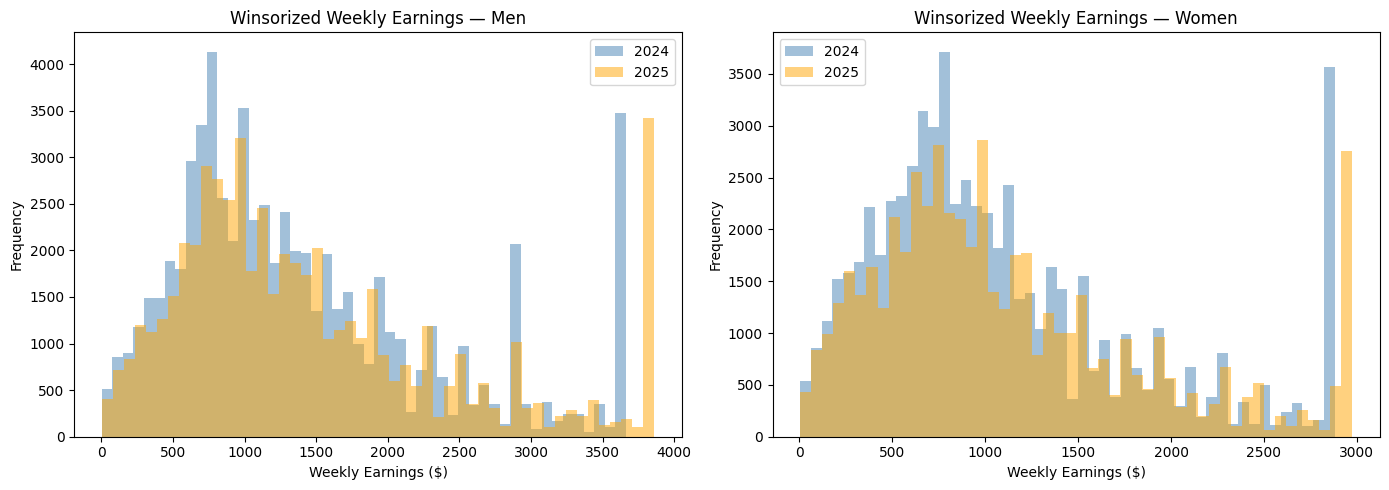

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Men
axes[0].hist(Men24_winsorized, bins=50, alpha=0.5, label='2024', color='steelblue')
axes[0].hist(Men25_winsorized, bins=50, alpha=0.5, label='2025', color='orange')
axes[0].set_title('Winsorized Weekly Earnings — Men')
axes[0].set_xlabel('Weekly Earnings ($)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

#Women
axes[1].hist(Women24_winsorized, bins=50, alpha=0.5, label='2024', color='steelblue')
axes[1].hist(Women25_winsorized, bins=50, alpha=0.5, label='2025', color='orange')
axes[1].set_title('Winsorized Weekly Earnings — Women')
axes[1].set_xlabel('Weekly Earnings ($)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('figure1_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

Both histograms show that winsorized weekly earnings are right-skewed for men and women alike, indicating that most workers earn in the lower-to-middle range. In contrast, a few workers (outliers) earn higher amounts closer to the upper end. These histograms also show that, in both years, the distribution is similar, with men having higher earnings.

# **Means with Confidence Interval Error Bars**

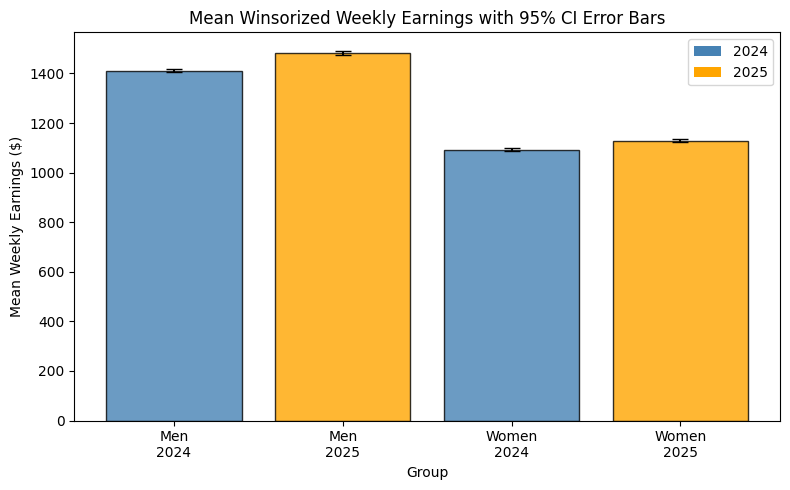

In [49]:
groups = ['Men\n2024', 'Men\n2025', 'Women\n2024', 'Women\n2025']
keys   = ['Men2024', 'Men2025', 'Women2024', 'Women2025']

means  = [results[k]['mean'] for k in keys]
errors = [results[k]['mean'] - results[k]['CI_lower'] for k in keys]  # half-width of CI
colors = ['steelblue', 'orange', 'steelblue', 'orange']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(groups, means, yerr=errors, capsize=6, color=colors,
              alpha=0.8, edgecolor='black')

ax.set_title('Mean Winsorized Weekly Earnings with 95% CI Error Bars')
ax.set_ylabel('Mean Weekly Earnings ($)')
ax.set_xlabel('Group')

# Custom legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='2024'),
                   Patch(facecolor='orange',    label='2025')]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig('figure2_means_ci.png', dpi=150, bbox_inches='tight')
plt.show()

This plot shows that mean winsorized weekly earnings increased from 2024 to 2025 for both genders; however, men still have a higher average in both years. The small 95% CI compared to the height of the bars suggests the estimated group means are precise, but the chart alone hides specific data of individual earnings by gender and year group.